# Task - data preparation, basic statistical analysis

You will try to process a very similar dataset as in the lecture. This time the house prices are from Portland and are relatively recent.

## Portland Housing Prices/Sales Jul 2020 - Jul 2021
- https://www.kaggle.com/datasets/threnjen/portland-housing-prices-sales-jul-2020-jul-2021
- 348 columns
- 25681 records

To make things easier, only some columns were selected from the original dataset and the number of records was also significantly reduced.

!!! For this reason, the subset created may not statistically match the original dataset.

A bonus task is to process the original dataset.

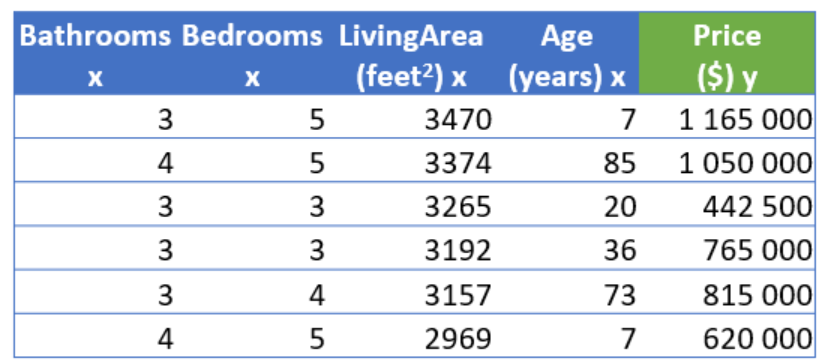

# Task

- Perform a statistical analysis of the data
- Visualize the data
- Select appropriate variables for the linear model
- Standardize the data

## Reading data from CSV file

In [47]:
%pip install seaborn



     -------------------------------------- 294.9/294.9 KB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\tsush\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip' command.


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
data = pd.read_csv ("..\\dataset\\portland_filtered.csv",  sep=';')


## Basic data characteristics
- data preview
- display of basic statistics (average, minimum, maximum, ...)
- checking NaN values

In [55]:
print("data preview")
print(data.info())
print("display of basic statistics")
print(data.describe())
print("checking NaN values")
print(data.isnull().sum())


data preview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   bathrooms   100 non-null    int64
 1   bedrooms    100 non-null    int64
 2   livingArea  100 non-null    int64
 3   age         100 non-null    int64
 4   price       100 non-null    int64
dtypes: int64(5)
memory usage: 4.0 KB
None
display of basic statistics
        bathrooms    bedrooms   livingArea        age         price
count  100.000000  100.000000   100.000000  100.00000  1.000000e+02
mean     2.380000    3.260000  1974.080000   49.88000  5.196074e+05
std      0.838228    0.860115   663.629851   32.77973  1.722241e+05
min      1.000000    1.000000   766.000000    3.00000  1.650000e+05
25%      2.000000    3.000000  1530.000000   20.00000  4.125000e+05
50%      2.000000    3.000000  1859.000000   47.50000  5.000000e+05
75%      3.000000    4.000000  2490.250000   75.25000  5.995312e

## Data distribution
- charts with data distribution
- boxplot charts
- describe what the data is (skewed values, ...)

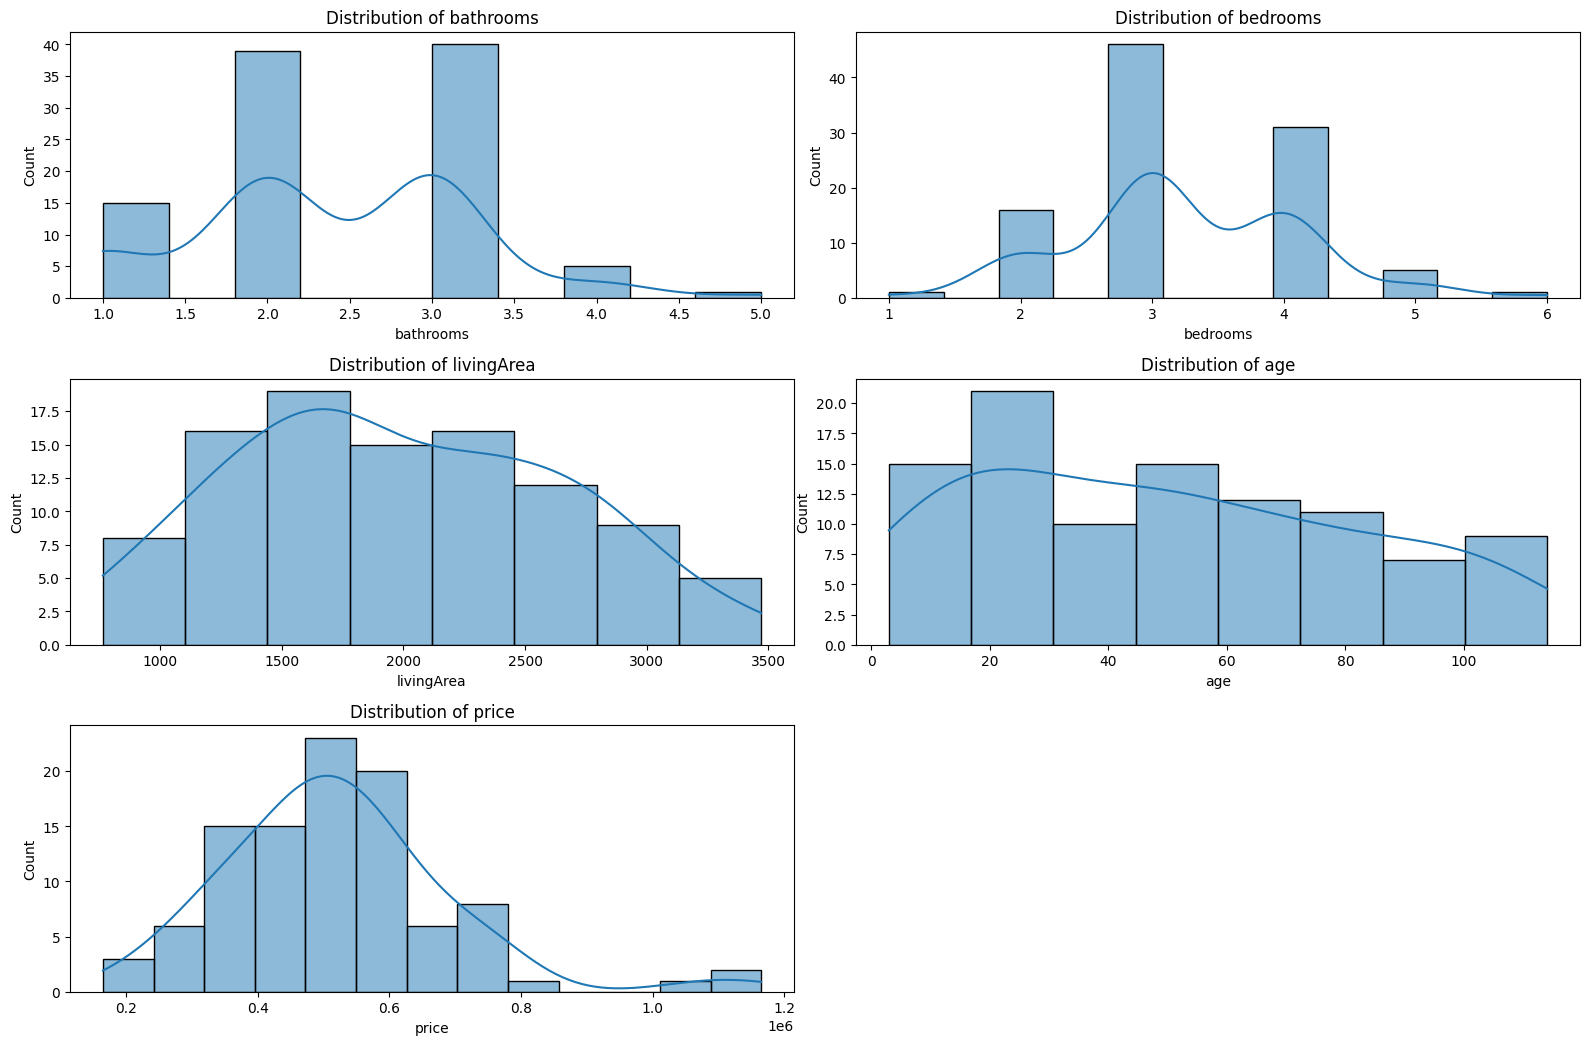

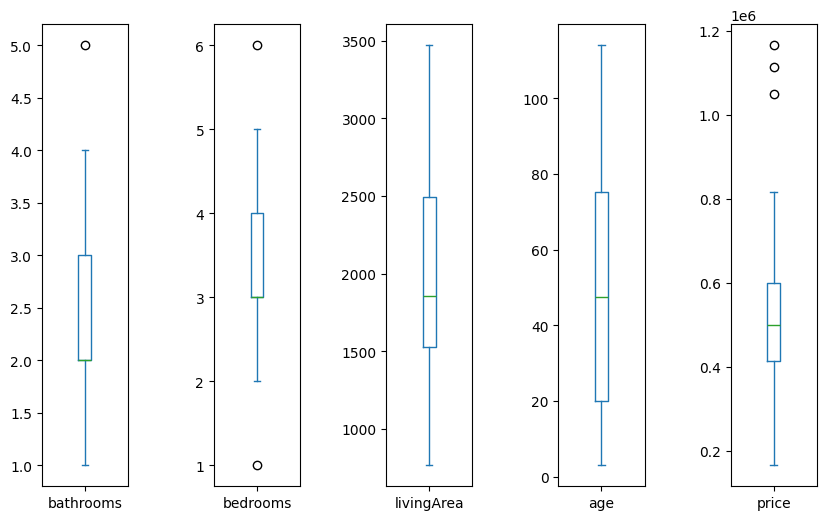

In [ ]:
pos = 1
fig = plt.figure(figsize=(16,24))

for col in data.columns:
    ax = fig.add_subplot(7,2,pos)
    pos += 1
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()



data.plot(kind='box', subplots=True, sharey=False, figsize=(10, 6))
plt.subplots_adjust(wspace=1) 
plt.show()


# ===============================
# Explanation:
# Most variables are right-skewed.
# LivingArea and Price show strong skew and many high-value outliers.
# Bathrooms and Bedrooms have mild skew with most values in low ranges.
# Age is moderately skewed, with more newer than older homes.
# ===============================

## Relationships between data
- pairplot
- correlation table
- Determine which columns are linearly dependent, suitable for explaining price

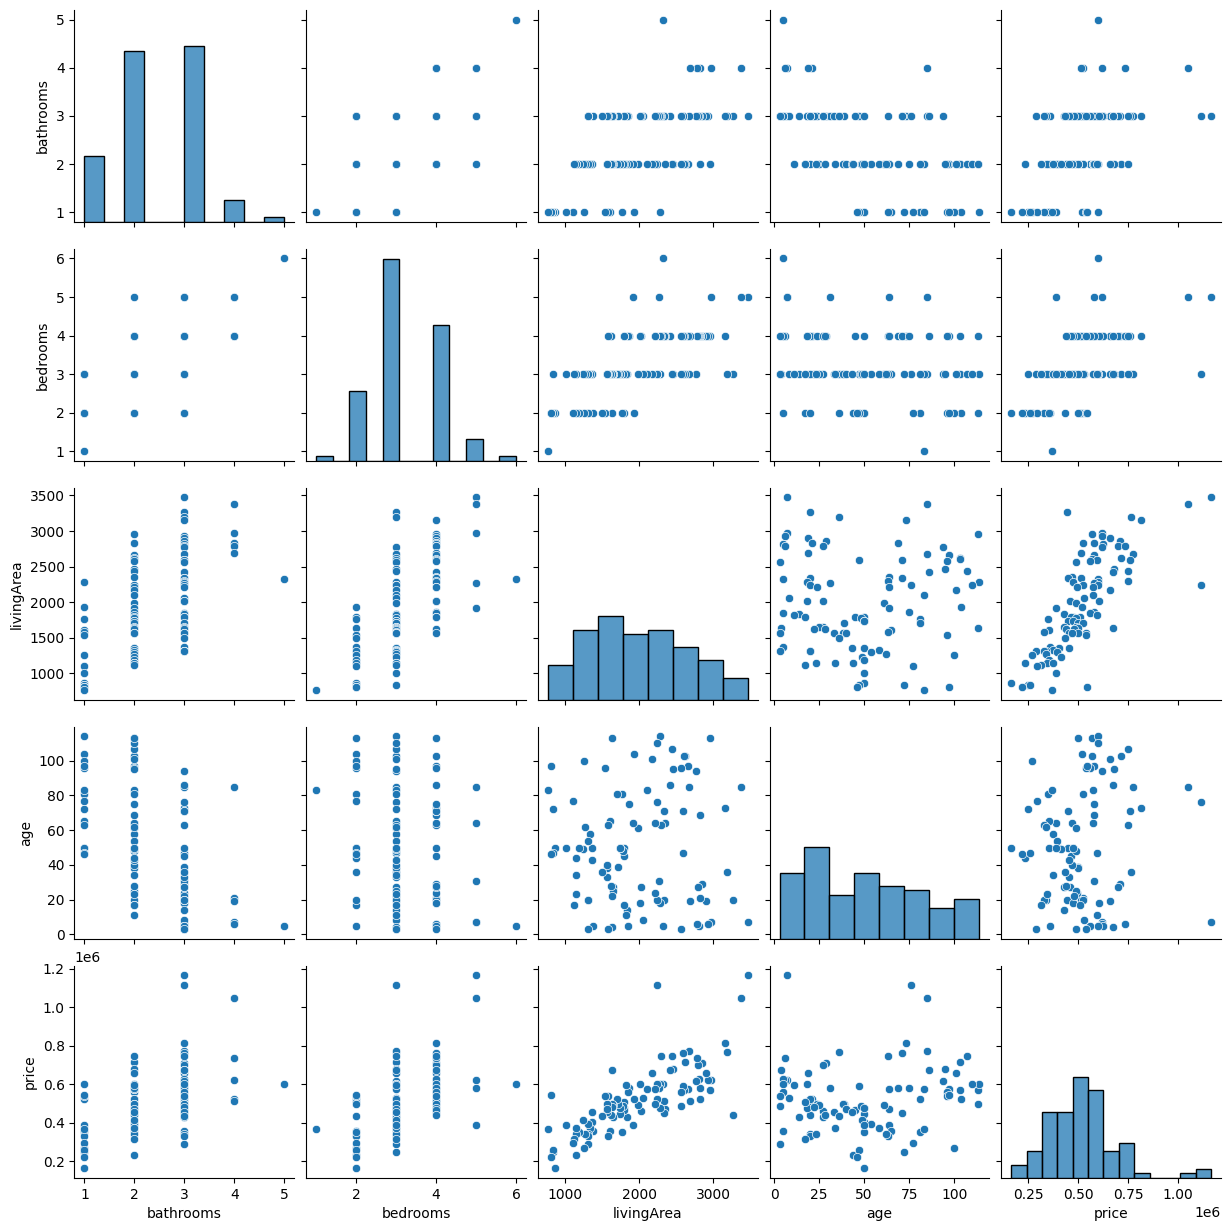

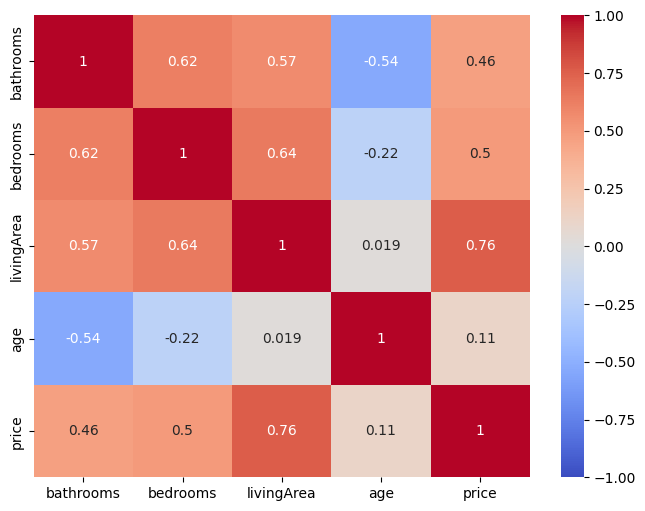

In [ ]:
sns.pairplot(data)
plt.show()


corr = data.corr()
corr

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmax=1, vmin=-1)
plt.show()


# ===============================
# Explanation:
# livingArea strongly correlates with price
# bathrooms and bedrooms moderately correlate
# age may have weak or negative correlation
# ===============================


## Data standardization

Each function has a different mean, standard deviation.

Standardization center and scale function.

Reasons:
* to prevent some functions from dominating the model.
* can help machine learning models converge faster
* can facilitate interpretation of machine learning model coefficients

Calculation:
* x_new = (x - mean) / standard_deviation
* mean = sum of (x) / number of (x)
* standard_deviation = sqrt( sum ( (x - mean)^2 ) / count (x))

- perform the standardization of the columns used for the linear regression
- show the distribution of the original and standardised data
*** Translated with www.DeepL.com/Translator (free version) ***



In [67]:
features = ["bathrooms", "bedrooms", "livingArea", "age"]

means = data[features].mean()
stds = data[features].std()

data_std = data.copy()
data_std[features] = (data[features] - means) / stds

data_std.head()




,bathrooms,bedrooms,livingArea,age,price
0,0.739656,2.022985,2.254148,-1.308125,1165000
1,1.932648,2.022985,2.109489,1.071394,1050000
2,0.739656,-0.302285,1.945241,-0.911539,442500
3,0.739656,-0.302285,1.835240,-0.423432,765000
4,0.739656,0.860350,1.782500,0.705314,815000


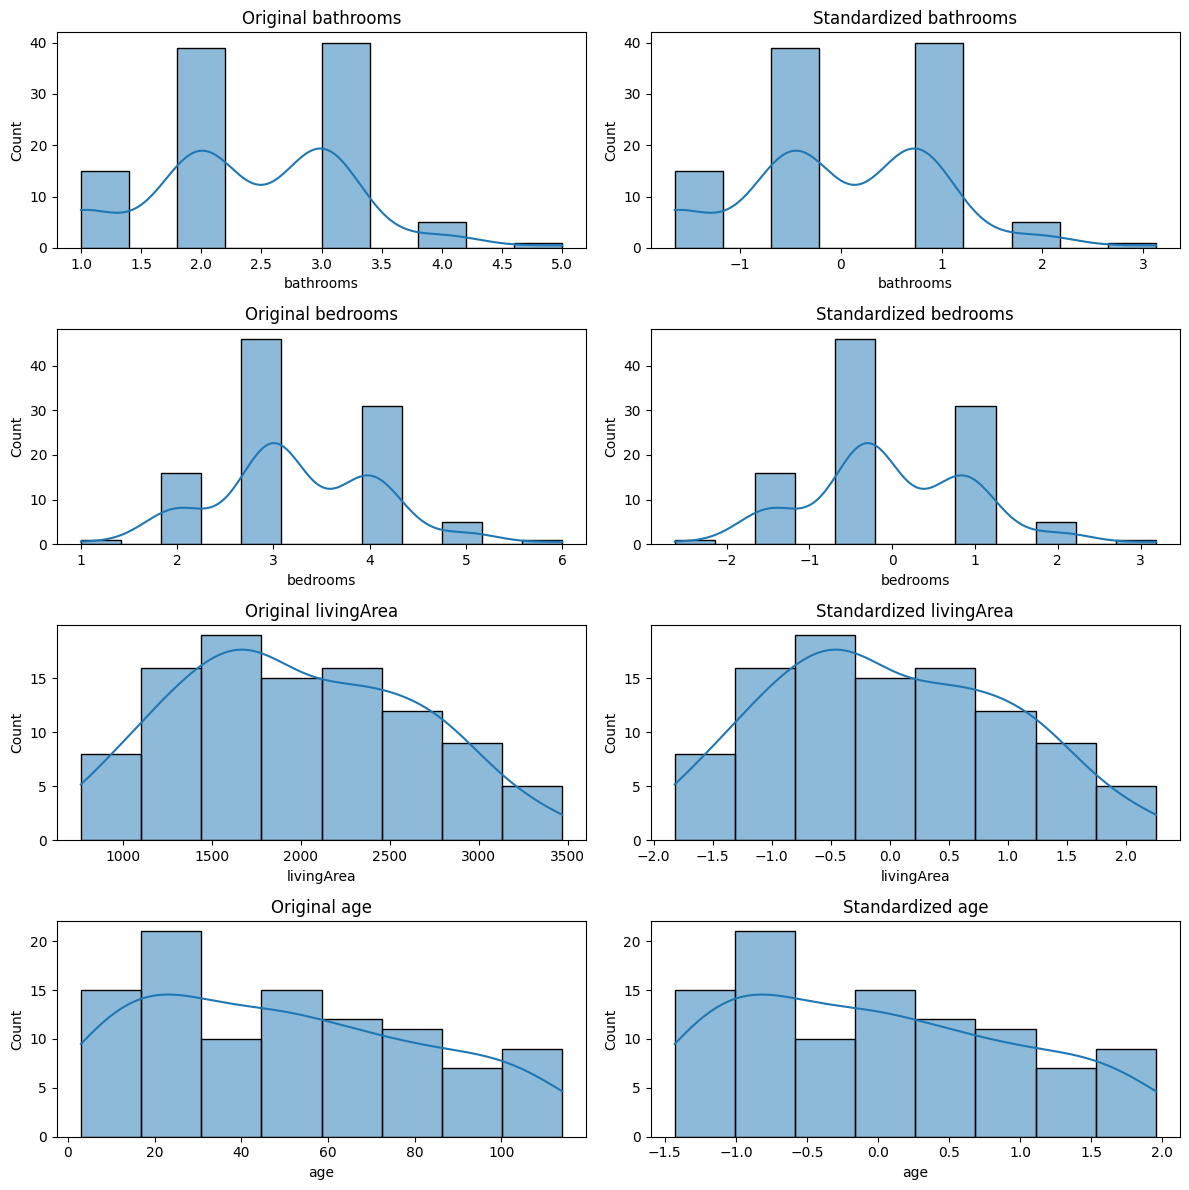

In [68]:
fig, axes = plt.subplots(len(features), 2, figsize=(12,12))

for i, col in enumerate(features):
    sns.histplot(data[col], kde=True, ax=axes[i,0])
    axes[i,0].set_title(f"Original {col}")

    sns.histplot(data_std[col], kde=True, ax=axes[i,1])
    axes[i,1].set_title(f"Standardized {col}")

plt.tight_layout()
plt.show()
